# End-to-End ML Pipeline: Tesla Deliveries Forecasting

**Project Description**  
Designed and implemented an end-to-end ML pipeline on sales/price data covering:
- Data Loading
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

Dataset: Tesla Deliveries (2015–2025)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\laksh\Downloads\tesla_deliveries_dataset_2015_2025.csv")
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.info()


Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_

## Data Cleaning

In [5]:
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Exploratory Data Analysis (EDA)

In [6]:
df.describe(include='all')


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


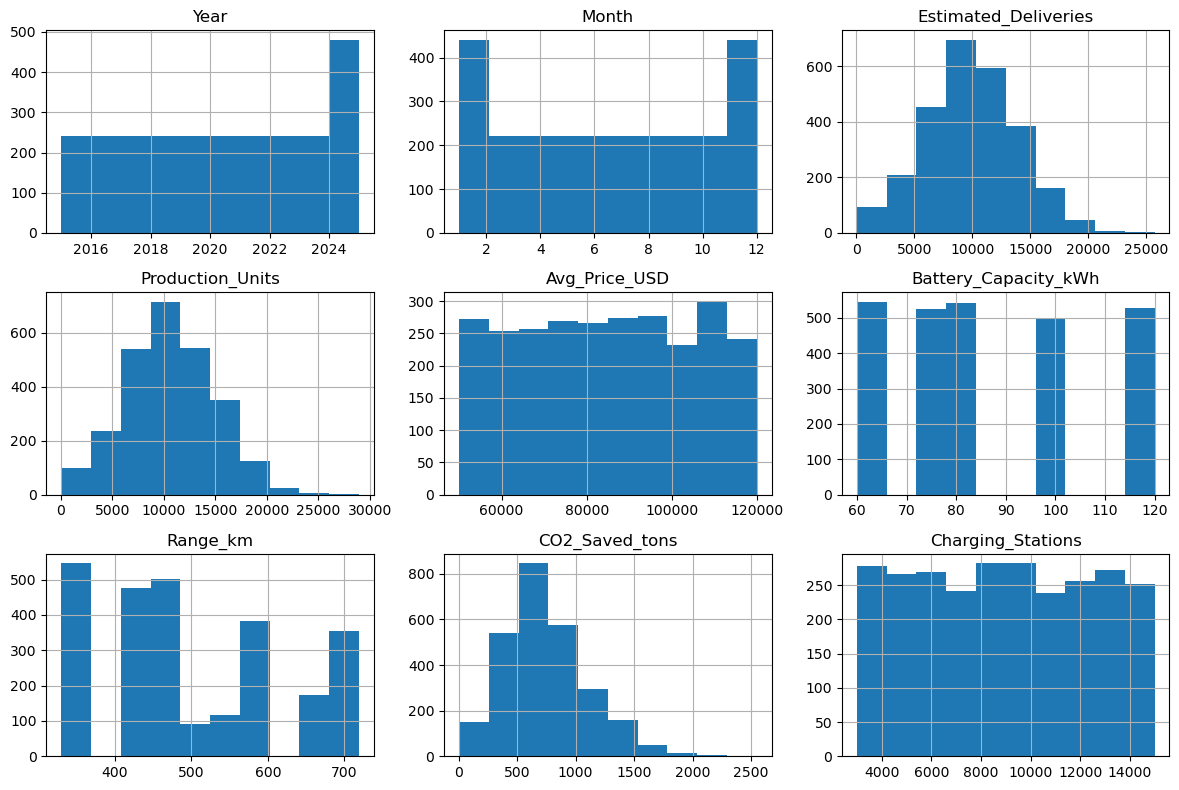

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    df[numeric_cols].hist(figsize=(12,8))
    plt.tight_layout()
    plt.show()


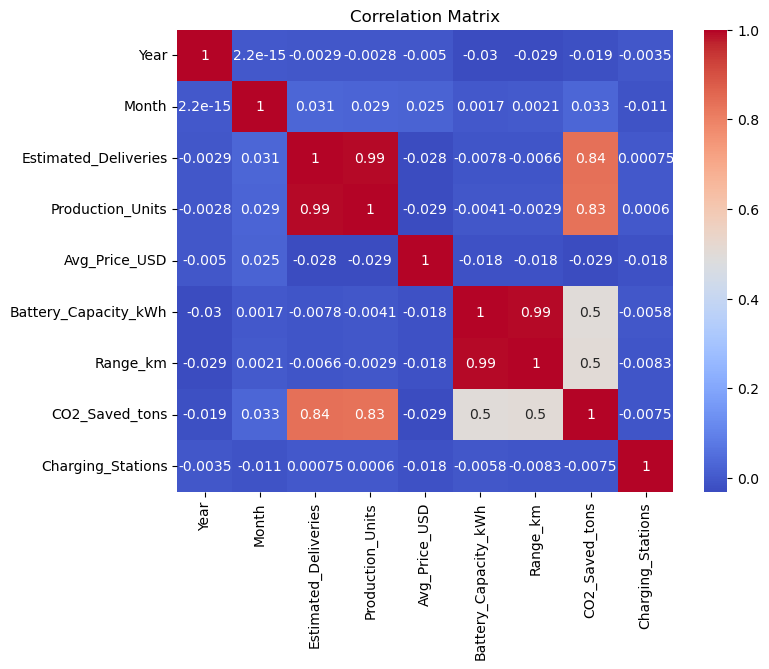

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()


## Feature Engineering

In [26]:
df = df.sort_values(['Year', 'Month'])


df['Estimated_Deliveries'] = pd.to_numeric(
    df['Estimated_Deliveries'],
    errors='coerce'
)

df['Production_Units'] = pd.to_numeric(
    df['Production_Units'],
    errors='coerce'
)

# Delivery growth compared to previous month
df['Delivery_Growth_%'] = (
    df['Estimated_Deliveries']
    .pct_change()
) * 100

# Production efficiency
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

df.fillna(0, inplace=True)
df.drop(columns=['Prev_Month_Deliveries'], inplace=True)
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Range_km_month,Range_km_quarter,CO2_Saved_tons_year,CO2_Saved_tons_month,CO2_Saved_tons_quarter,Charging_Stations_year,Charging_Stations_month,Charging_Stations_quarter,Delivery_Growth_%,Production_Efficiency
644,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000000001,Middle East,Model Y,10348,10835,1970-01-01 00:00:00.000085599,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000488,1970-01-01 00:00:00.000000757,...,1,1,1970,1,1,1970,1,1,0.000000,0.955053
872,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000000001,Asia,Model Y,12446,13885,1970-01-01 00:00:00.000055183,1970-01-01 00:00:00.000000060,1970-01-01 00:00:00.000000340,1970-01-01 00:00:00.000000634,...,1,1,1970,1,1,1970,1,1,20.274449,0.896363
904,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000000001,Europe,Model Y,10835,11723,1970-01-01 00:00:00.000062939,1970-01-01 00:00:00.000000120,1970-01-01 00:00:00.000000718,1970-01-01 00:00:00.000001166,...,1,1,1970,1,1,1970,1,1,-12.943918,0.924251
1199,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000000001,North America,Model X,8122,8343,1970-01-01 00:00:00.000062838,1970-01-01 00:00:00.000000075,1970-01-01 00:00:00.000000423,1970-01-01 00:00:00.000000515,...,1,1,1970,1,1,1970,1,1,-25.039225,0.973511
1228,1970-01-01 00:00:00.000002015,1970-01-01 00:00:00.000000001,Middle East,Model S,13902,15423,1970-01-01 00:00:00.000094629,1970-01-01 00:00:00.000000075,1970-01-01 00:00:00.000000445,1970-01-01 00:00:00.000000927,...,1,1,1970,1,1,1970,1,1,71.164738,0.901381


## Regression Modeling

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

target = df.select_dtypes(include='number').columns[-1]

X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))


R2: 0.8787114236306711
MAE: 0.007524447987793044


## Hyperparameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV

params = {
    'regressor__n_estimators':[100,200],
    'regressor__max_depth':[3,5,10,None]
}

grid = GridSearchCV(
    model,
    params,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Params: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
Best Score: 0.8079671635046569


## Time Series Forecasting

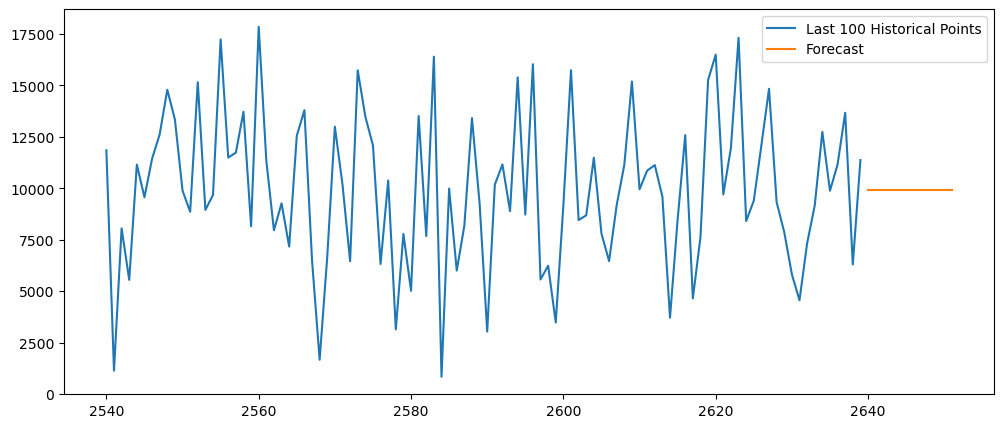

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.plot(
    df['Time_Index'][-100:],
    y[-100:],
    label='Last 100 Historical Points'
)

plt.plot(
    future['Time_Index'],
    future_predictions,
    label='Forecast'
)

plt.legend()
plt.show()